# Эллиптические уравнения: В поисках равновесия #

На этом занятии мы исследуем численные методы решения эллиптических уравнений 
на примере уравнения Лапласа в 2D:

$$\nabla^2 u = \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 0$$

Это уравнение описывает стационарное (установившееся) состояние системы, 
когда все переходные процессы закончились. Решение отвечает на вопрос: 
"Каким будет **финальное распределение** температуры/потенциала/давления?"

Мы реализуем и сравним три итерационных метода решения:
1. **Метод Якоби** - простой, медленно сходящийся, легко распараллеливается
2. **Метод Гаусса-Зейделя** - использует обновленные значения, сходится быстрее
3. **Метод SOR** (Successive Over-Relaxation) - ускоренная версия Гаусса-Зейделя

Также решим уравнение Пуассона с источником тепла:

$$\nabla^2 u = -f(x,y)$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

## Параметры задачи ##

In [ ]:
# Размеры области
Lx = 1.0          # длина по x, м
Ly = 1.0          # длина по y, м
Nx = 50           # количество узлов по x
Ny = 50           # количество узлов по y
dx = Lx / (Nx - 1)  # шаг по x
dy = Ly / (Ny - 1)  # шаг по y

# Параметры итерационного процесса
max_iterations = 5000  # максимальное число итераций
tolerance = 1e-4       # критерий сходимости
omega = 1.5            # параметр релаксации для SOR (1 < ω < 2)

# Сетка
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y)

print(f"Параметры численной схемы:")
print(f"  Размер области: {Lx} × {Ly} м")
print(f"  Сетка: {Nx} × {Ny} узлов")
print(f"  Шаги: dx = {dx:.4f} м, dy = {dy:.4f} м")
print(f"  Максимум итераций: {max_iterations}")
print(f"  Критерий сходимости: {tolerance}")
print(f"  Параметр релаксации ω = {omega}")

Параметры численной схемы:
  Размер области: 1.0 × 1.0 м
  Сетка: 50 × 50 узлов
  Шаги: dx = 0.0204 м, dy = 0.0204 м
  Максимум итераций: 5000
  Критерий сходимости: 0.0001
  Параметр релаксации ω = 1.5


## Граничные условия ##

In [ ]:
def set_boundary_conditions(U, case='top_hot'):
    """
    Установка граничных условий
    
    Args:
        U: массив температуры (Ny, Nx)
        case: тип граничных условий
            'top_hot' - верхняя граница горячая (T=100), остальные холодные (T=0)
            'left_right' - левая граница горячая, правая холодная
            'corners' - горячие углы
    
    Returns:
        U: массив с установленными граничными условиями
    """
    if case == 'top_hot':
        U[0, :] = 100.0   # верхняя граница
        U[-1, :] = 0.0    # нижняя граница
        U[:, 0] = 0.0     # левая граница
        U[:, -1] = 0.0    # правая граница
    
    elif case == 'left_right':
        U[:, 0] = 100.0   # левая граница горячая
        U[:, -1] = 0.0    # правая граница холодная
        # U[0, :] = 50.0    # верхняя граница
        # U[-1, :] = 50.0   # нижняя граница

    elif case == 'corners':
        # Горячие углы, остальные границы холодные
        U[0, :] = 0.0
        U[-1, :] = 0.0
        U[:, 0] = 0.0
        U[:, -1] = 0.0
        U[0, 0] = 100.0
        U[0, -1] = 100.0
        U[-1, 0] = 100.0
        U[-1, -1] = 100.0
    
    return U

Уравнение Пуассона с источником тепла ##

In [ ]:
def create_heat_source(X, Y, source_type='center_spot'):
    """
    Создание функции источника тепла f(x,y)
    
    Args:
        X, Y: координатные сетки
        source_type: тип источника
            'center_spot' - горячее пятно в центре
            'line' - линейный источник
            'multiple' - несколько источников
    
    Returns:
        f: массив плотности источников тепла
    """
    f = np.zeros_like(X)
    
    if source_type == 'center_spot':
        # Гауссово пятно в центре
        x0, y0 = Lx/2, Ly/2
        sigma = 0.1
        f = 100 * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))
    
    elif source_type == 'line':
        # Линейный источник (вертикальная линия)
        mask = (np.abs(X - Lx/2) < 0.05)
        f[mask] = 50.0
    
    elif source_type == 'multiple':
        # Несколько точечных источников
        sources = [(0.3, 0.3, 80), (0.7, 0.7, 60), (0.3, 0.7, 40), (0.7, 0.3, 50)]
        for x0, y0, intensity in sources:
            sigma = 0.08
            f += intensity * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))
    
    return f

## Визуализация ##

In [ ]:
def plot_temperature_field(X, Y, U, title='Распределение температуры'):
    """
    Визуализация 2D поля температуры
    
    Args:
        X, Y: координатные сетки
        U: поле температуры
        title: заголовок графика
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # 2D colormap
    im1 = ax1.contourf(X, Y, U, levels=20, cmap='hot')
    ax1.set_xlabel('x, м', fontsize=12)
    ax1.set_ylabel('y, м', fontsize=12)
    ax1.set_title(title, fontsize=14)
    ax1.set_aspect('equal')
    plt.colorbar(im1, ax=ax1, label='Температура, °C')
    
    # 3D surface

    ax2 = fig.add_subplot(122, projection='3d')
    surf = ax2.plot_surface(X, Y, U, cmap='hot', edgecolor='none', alpha=0.8)
    ax2.set_xlabel('x, м', fontsize=10)
    ax2.set_ylabel('y, м', fontsize=10)
    ax2.set_zlabel('T, °C', fontsize=10)
    ax2.set_title(title, fontsize=14)
    plt.colorbar(surf, ax=ax2, shrink=0.5, label='Температура, °C')
    
    plt.tight_layout()
    plt.show()

In [ ]:
def create_convergence_animation(X, Y, history, method_name='', skip_frames=10):
    """
    Создание анимации процесса сходимости
    
    Args:
        X, Y: координатные сетки
        history: список состояний [U_0, U_1, ..., U_final]
        method_name: название метода
        skip_frames: показывать каждый N-й кадр
        
    Returns:
        animation объект
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Начальное состояние
    im = ax.contourf(X, Y, history[0], levels=20, cmap='hot', vmin=0, vmax=100)
    ax.set_xlabel('x, м', fontsize=12)
    ax.set_ylabel('y, м', fontsize=12)
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, label='Температура, °C')
    
    title = ax.text(0.5, 1.05, '', transform=ax.transAxes, 
                    fontsize=14, ha='center', weight='bold')
    
    # Отбираем кадры
    frames_to_show = history[::skip_frames]
    
    def animate(i):
        ax.clear()
        im = ax.contourf(X, Y, frames_to_show[i], levels=20, cmap='hot', vmin=0, vmax=100)
        ax.set_xlabel('x, м', fontsize=12)
        ax.set_ylabel('y, м', fontsize=12)
        ax.set_aspect('equal')
        iteration = i * skip_frames
        ax.set_title(f'{method_name}: итерация {iteration}', fontsize=14, weight='bold')
        return [im]
    
    anim = FuncAnimation(fig, animate, frames=len(frames_to_show), 
                        interval=50, blit=False, repeat=True)
    
    plt.close()
    return anim

## 1. Метод Якоби для уравнения Лапласа ##

In [ ]:
def solve_laplace_jacobi(U0, max_iter=5000, tol=1e-8):
    """
    Решение уравнения Лапласа методом Якоби
    
    Схема: U_new[i,j] = (U_old[i+1,j] + U_old[i-1,j] + U_old[i,j+1] + U_old[i,j-1]) / 4
    
    На каждой итерации все точки обновляются одновременно на основе значений 
    с предыдущей итерации. Метод медленно сходится, но легко распараллеливается.
    
    Args:
        U0: начальное приближение с граничными условиями
        max_iter: максимальное число итераций
        tol: критерий сходимости (max изменение)
        
    Returns:
        U: решение
        iterations: число выполненных итераций
    """
    U_old = U0.copy()
    U_new = U0.copy()
    
    history = []
    history.append(U_old.copy())
    
    for iteration in range(max_iter):
        # Обновляем все внутренние точки одновременно
        U_new[1:-1, 1:-1] = 0.25 * (U_old[2:, 1:-1] + U_old[:-2, 1:-1] + 
                                     U_old[1:-1, 2:] + U_old[1:-1, :-2])
        
        # Проверка сходимости
        max_diff = np.max(np.abs(U_new - U_old))
        
        if iteration % 10 == 0:
            history.append(U_new.copy())
        
        if max_diff < tol:
            print(f"Метод Якоби сошелся за {iteration + 1} итераций (max_diff = {max_diff:.2e})")
            return U_new, iteration + 1, history
        
        U_old = U_new.copy()
    
    print(f"Метод Якоби: достигнуто максимальное число итераций ({max_iter})")
    return U_new, max_iter, history

Метод Якоби сошелся за 1442 итераций (max_diff = 9.99e-05)


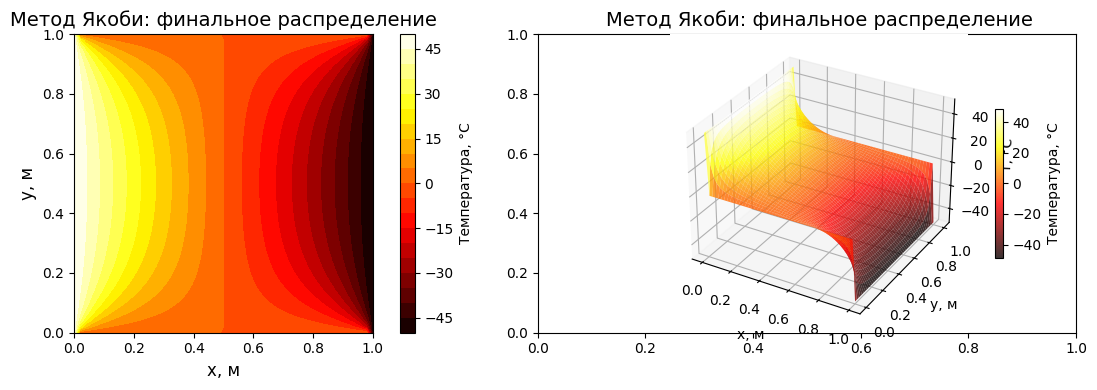

In [ ]:
# Решаем уравнение Лапласа методом Якоби

U0_jacobi = np.zeros((Ny, Nx))
U0_jacobi = set_boundary_conditions(U0_jacobi, case='left_right')

U_jacobi, iter_jacobi, history_jacobi = solve_laplace_jacobi(
    U0_jacobi, max_iter=max_iterations, tol=tolerance
)

plot_temperature_field(X, Y, U_jacobi, title='Метод Якоби: финальное распределение')

anim_jacobi = create_convergence_animation(X, Y, history_jacobi, 
                                           method_name='Метод Якоби', skip_frames=1)

HTML(anim_jacobi.to_jshtml())

## 2. Метод Гаусса-Зейделя для уравнения Лапласа ##

In [ ]:
def solve_laplace_gauss_seidel(U0, max_iter=5000, tol=1e-4):
    """
    Решение уравнения Лапласа методом Гаусса-Зейделя
    
    Схема: U[i,j] = (U[i+1,j] + U[i-1,j] + U[i,j+1] + U[i,j-1]) / 4
    
    Отличие от Якоби: при обновлении точки (i,j) используются УЖЕ обновленные 
    значения из этой же итерации. Это ускоряет сходимость в ~2 раза.
    
    Args:
        U0: начальное приближение с граничными условиями
        max_iter: максимальное число итераций
        tol: критерий сходимости
        
    Returns:
        U: решение
        iterations: число итераций
    """
    U = U0.copy()
    
    history = []
    history.append(U.copy())
    
    for iteration in range(max_iter):
        U_old = U.copy()
        
        # Обновляем точки последовательно, используя уже обновленные значения
        for i in range(1, Ny - 1):
            for j in range(1, Nx - 1):
                U[i, j] = 0.25 * (U[i+1, j] + U[i-1, j] + U[i, j+1] + U[i, j-1])
        
        # Проверка сходимости
        max_diff = np.max(np.abs(U - U_old))
        
        if iteration % 5 == 0:
            history.append(U.copy())
        
        if max_diff < tol:
            print(f"Метод Гаусса-Зейделя сошелся за {iteration + 1} итераций (max_diff = {max_diff:.2e})")
            return U, iteration + 1, history
        
    print(f"Метод Гаусса-Зейделя: достигнуто максимальное число итераций ({max_iter})")
    return U, max_iter, history

In [ ]:
# Решаем уравнение Лапласа методом Гаусса-Зейделя

U0_gs = np.zeros((Ny, Nx))
U0_gs = set_boundary_conditions(U0_gs, case='top_hot')

U_gs, iter_gs, history_gs = solve_laplace_gauss_seidel(
    U0_gs, max_iter=max_iterations, tol=tolerance
)

plot_temperature_field(X, Y, U_gs, title='Метод Гаусса-Зейделя: финальное распределение')

anim_gs = create_convergence_animation(X, Y, history_gs, 
                                       method_name='Метод Гаусса-Зейделя', skip_frames=5)
HTML(anim_gs.to_jshtml())

## 3. Метод последовательной сверхрелаксации (SOR) ##

In [ ]:
def solve_laplace_sor(U0, omega=1.5, max_iter=5000, tol=1e-4):
    """
    Решение уравнения Лапласа методом SOR
    
    Схема: U_new = U_old + ω * (U_GS - U_old)
    где U_GS - значение по Гауссу-Зейделю
    
    Метод SOR - это "усиленная" версия Гаусса-Зейделя. Мы делаем шаг в сторону
    равновесия не на величину (U_GS - U_old), а на ω раз больше. При правильном 
    выборе ω (обычно 1 < ω < 2) сходимость ускоряется в разы!
    
    Args:
        U0: начальное приближение
        omega: параметр релаксации (1 < ω < 2)
        max_iter: максимальное число итераций
        tol: критерий сходимости
        
    Returns:
        U: решение
        iterations: число итераций
    """
    U = U0.copy()
    
    history = []
    history.append(U.copy())
    
    for iteration in range(max_iter):
        U_old = U.copy()
        
        for i in range(1, Ny - 1):
            for j in range(1, Nx - 1):
                # Значение по Гауссу-Зейделю
                U_gs = 0.25 * (U[i+1, j] + U[i-1, j] + U[i, j+1] + U[i, j-1])
                # Применяем сверхрелаксацию
                U[i, j] = U[i, j] + omega * (U_gs - U[i, j])
        
        max_diff = np.max(np.abs(U - U_old))
        
        if iteration % 3 == 0:
            history.append(U.copy())
        
        if max_diff < tol:
            print(f"Метод SOR (ω={omega}) сошелся за {iteration + 1} итераций (max_diff = {max_diff:.2e})")
            return U, iteration + 1, history
    
    print(f"Метод SOR: достигнуто максимальное число итераций ({max_iter})")
    return U, max_iter, history

In [ ]:
# Решаем уравнение Лапласа методом SOR

U0_sor = np.zeros((Ny, Nx))
U0_sor = set_boundary_conditions(U0_sor, case='top_hot')

U_sor, iter_sor, history_sor = solve_laplace_sor(
    U0_sor, omega=omega, max_iter=max_iterations, tol=tolerance
)

plot_temperature_field(X, Y, U_sor, title=f'Метод SOR (ω={omega}): финальное распределение')

# anim_sor = create_convergence_animation(X, Y, history_sor, 
#                                         method_name=f'Метод SOR (ω={omega})', skip_frames=3)
# HTML(anim_sor.to_jshtml())

## Сравнение скорости сходимости методов ##

In [ ]:
# Визуализация сравнения
fig, ax = plt.subplots(figsize=(10, 6))

methods = ['Якоби', 'Гаусс-Зейдель', f'SOR (ω={omega})']
iterations = [iter_jacobi, iter_gs, iter_sor]
colors = ['blue', 'green', 'red']

bars = ax.bar(methods, iterations, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Добавляем значения на столбцы
for bar, iter_count in zip(bars, iterations):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{iter_count}',
            ha='center', va='bottom', fontsize=14, weight='bold')

ax.set_ylabel('Число итераций', fontsize=14)
ax.set_title('Сравнение скорости сходимости методов решения уравнения Лапласа', 
             fontsize=14, weight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("СРАВНЕНИЕ МЕТОДОВ:")
print("="*60)
print(f"{'Метод':<20} {'Итераций':<15} {'Ускорение'}")
print("-"*60)
print(f"{'Якоби':<20} {iter_jacobi:<15} {'1.00x'}")
print(f"{'Гаусс-Зейдель':<20} {iter_gs:<15} {f'{iter_jacobi/iter_gs:.2f}x'}")
print(f"{'SOR (ω={omega})':<20} {iter_sor:<15} {f'{iter_jacobi/iter_sor:.2f}x'}")
print("="*60)

## Уравнение Пуассона: Метод Якоби ##

In [ ]:
def solve_poisson_jacobi(U0, f, dx, dy, max_iter=5000, tol=1e-4):
    """
    Решение уравнения Пуассона методом Якоби
    
    Уравнение: ∇²u = -f(x,y)
    
    Схема (dx=dy):
        U_new[i,j] = 0.25 * (U_old[i+1,j] + U_old[i-1,j] + U_old[i,j+1] + U_old[i,j-1] - f[i,j]*dx²)
    
    Args:
        U0: начальное приближение
        f: функция источника
        dx, dy: шаги сетки
        max_iter: максимум итераций
        tol: критерий сходимости
        
    Returns:
        U: решение
        iterations: число итераций
    """
    U_old = U0.copy()
    U_new = U0.copy()
    
    for iteration in range(max_iter):
        U_new[1:-1, 1:-1] = 0.25 * (
            U_old[2:, 1:-1] + U_old[:-2, 1:-1] + U_old[1:-1, 2:] + U_old[1:-1, :-2] - f[1:-1, 1:-1] * dx**2
        )
        
        max_diff = np.max(np.abs(U_new - U_old))
        if max_diff < tol:
            print(f"Пуассон-Якоби: сошёлся за {iteration + 1} итераций (max_diff = {max_diff:.2e})")
            return U_new, iteration + 1
        U_old = U_new.copy()
    
    print(f"Пуассон-Якоби: достигнуто максимальное число итераций ({max_iter})")
    return U_new, max_iter

## Уравнение Пуассона: Метод Гаусса-Зейделя ##

In [ ]:
def solve_poisson_gauss_seidel(U0, f, dx, dy, max_iter=5000, tol=1e-4):
    """
    Решение уравнения Пуассона методом Гаусса-Зейделя
    
    Уравнение: ∇²u = -f(x,y)
    
    Схема (dx=dy):
        U[i,j] = 0.25 * (U[i+1,j] + U[i-1,j] + U[i,j+1] + U[i,j-1] - f[i,j]*dx²)
    
    Args:
        U0: начальное приближение
        f: функция источника
        dx, dy: шаги сетки
        max_iter: максимум итераций
        tol: критерий сходимости
        
    Returns:
        U: решение
        iterations: число итераций
    """
    U = U0.copy()
    
    for iteration in range(max_iter):
        U_prev = U.copy()
        for i in range(1, Ny - 1):
            for j in range(1, Nx - 1):
                U[i, j] = 0.25 * (U[i+1, j] + U[i-1, j] + U[i, j+1] + U[i, j-1] - f[i, j] * dx**2)
        
        max_diff = np.max(np.abs(U - U_prev))
        if max_diff < tol:
            print(f"Пуассон-Гаусс-Зейдель: сошёлся за {iteration + 1} итераций (max_diff = {max_diff:.2e})")
            return U, iteration + 1
    
    print(f"Пуассон-Гаусс-Зейдель: достигнуто максимальное число итераций ({max_iter})")
    return U, max_iter

## Уравнение Пуассона: Метод SOR ##

In [ ]:
def solve_poisson_sor(U0, f, dx, dy, omega=1.5, max_iter=5000, tol=1e-4):
    """
    Решение уравнения Пуассона методом SOR
    
    Уравнение: ∇²u = -f(x,y)
    
    Схема: U_new = U_old + ω * (U_GS - U_old)
    где U_GS = (U[i+1,j] + U[i-1,j] + U[i,j+1] + U[i,j-1] + f[i,j]*dx²) / 4
    
    Args:
        U0: начальное приближение
        f: функция источника
        dx, dy: шаги сетки
        omega: параметр релаксации
        max_iter: максимум итераций
        tol: критерий сходимости
        
    Returns:
        U: решение
        iterations: число итераций
    """
    U = U0.copy()
    
    for iteration in range(max_iter):
        U_old = U.copy()
        
        for i in range(1, Ny - 1):
            for j in range(1, Nx - 1):
                # Гаусс-Зейдель с источником
                U_gs = 0.25 * (U[i+1, j] + U[i-1, j] + U[i, j+1] + U[i, j-1] - f[i, j] * dx**2)
                # Сверхрелаксация
                U[i, j] = U[i, j] + omega * (U_gs - U[i, j])
        
        max_diff = np.max(np.abs(U - U_old))
        
        if max_diff < tol:
            print(f"Уравнение Пуассона: сошлось за {iteration + 1} итераций (max_diff = {max_diff:.2e})")
            return U, iteration + 1
    
    print(f"Уравнение Пуассона: достигнуто максимальное число итераций ({max_iter})")
    return U, max_iter

## Уравнение Пуассона: Запуск трёх методов и сравнение ##

In [ ]:
# Источник тепла (центр)
f_center = create_heat_source(X, Y, source_type='center_spot')

# Единые граничные условия: все границы холодные (0)
U0_poisson_base = np.zeros((Ny, Nx))
U0_poisson_base[:, :] = 0.0

# Якоби
U0_p_j = U0_poisson_base.copy()
U_p_jacobi, iter_p_jacobi = solve_poisson_jacobi(
    U0_p_j, f_center, dx, dy, max_iter=max_iterations, tol=tolerance
)

# Гаусс–Зейдель
U0_p_gs = U0_poisson_base.copy()
U_p_gs, iter_p_gs = solve_poisson_gauss_seidel(
    U0_p_gs, f_center, dx, dy, max_iter=max_iterations, tol=tolerance
)

# SOR
U0_p_sor = U0_poisson_base.copy()
U_p_sor, iter_p_sor = solve_poisson_sor(
    U0_p_sor, f_center, dx, dy, omega=omega, max_iter=max_iterations, tol=tolerance
)

# Визуализация источника и трёх решений
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Источник тепла
im0 = axes[0].contourf(X, Y, f_center, levels=20, cmap='Reds')
axes[0].set_xlabel('x, м', fontsize=12)
axes[0].set_ylabel('y, м', fontsize=12)
axes[0].set_title('Источник f(x,y)', fontsize=14, weight='bold')
axes[0].set_aspect('equal')
plt.colorbar(im0, ax=axes[0], label='Плотность, Вт/м²')

im1 = axes[1].contourf(X, Y, U_p_jacobi, levels=20, cmap='hot')
axes[1].set_title(f'Пуассон: Якоби\n{iter_p_jacobi} итераций', fontsize=12)
axes[1].set_aspect('equal')
plt.colorbar(im1, ax=axes[1], label='T, °C')

im2 = axes[2].contourf(X, Y, U_p_gs, levels=20, cmap='hot')
axes[2].set_title(f'Пуассон: Гаусс-Зейдель\n{iter_p_gs} итераций', fontsize=12)
axes[2].set_aspect('equal')
plt.colorbar(im2, ax=axes[2], label='T, °C')

im3 = axes[3].contourf(X, Y, U_p_sor, levels=20, cmap='hot')
axes[3].set_title(f'Пуассон: SOR (ω={omega})\n{iter_p_sor} итераций', fontsize=12)
axes[3].set_aspect('equal')
plt.colorbar(im3, ax=axes[3], label='T, °C')

plt.tight_layout()
plt.show()

# Сравнение числа итераций
fig, ax = plt.subplots(figsize=(8, 5))
methods_p = ['Якоби', 'Гаусс-Зейдель', f'SOR (ω={omega})']
iters_p = [iter_p_jacobi, iter_p_gs, iter_p_sor]
colors_p = ['blue', 'green', 'red']

bars = ax.bar(methods_p, iters_p, color=colors_p, alpha=0.7, edgecolor='black', linewidth=2)
for bar, itc in zip(bars, iters_p):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{itc}',
            ha='center', va='bottom', fontsize=12, weight='bold')

ax.set_ylabel('Число итераций', fontsize=12)
ax.set_title('Уравнение Пуассона: сравнение скорости сходимости', fontsize=13, weight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Уравнение Пуассона: несколько источников (для SOR) ##

In [ ]:
f_multiple = create_heat_source(X, Y, source_type='multiple')
U0_multi = np.zeros((Ny, Nx))
U_multi, iter_multi = solve_poisson_sor(
    U0_multi, f_multiple, dx, dy, omega=omega, max_iter=max_iterations, tol=tolerance
)
plot_temperature_field(X, Y, U_multi, title='Пуассон (SOR): несколько источников тепла')

## Исследование оптимального параметра релаксации ##

In [ ]:
def find_optimal_omega(U0, omega_values, max_iter=5000, tol=1e-4):
    """
    Поиск оптимального параметра релаксации ω
    
    Args:
        U0: начальное приближение
        omega_values: список значений ω для тестирования
        max_iter: максимум итераций
        tol: критерий сходимости
        
    Returns:
        results: список (omega, iterations)
    """
    results = []
    
    for omega in omega_values:
        U_test = U0.copy()
        
        for iteration in range(max_iter):
            U_old = U_test.copy()
            
            for i in range(1, Ny - 1):
                for j in range(1, Nx - 1):
                    U_gs = 0.25 * (U_test[i+1, j] + U_test[i-1, j] + 
                                   U_test[i, j+1] + U_test[i, j-1])
                    U_test[i, j] = U_test[i, j] + omega * (U_gs - U_test[i, j])
            
            max_diff = np.max(np.abs(U_test - U_old))
            
            if max_diff < tol:
                results.append((omega, iteration + 1))
                break
        else:
            results.append((omega, max_iter))
    
    return results

In [ ]:
# Исследуем влияние параметра ω

print("\n" + "="*60)
print("ИССЛЕДОВАНИЕ ОПТИМАЛЬНОГО ПАРАМЕТРА РЕЛАКСАЦИИ")
print("="*60)

omega_values = np.linspace(1.0, 1.95, 20)

U0_test = np.zeros((Ny, Nx))
U0_test = set_boundary_conditions(U0_test, case='top_hot')

results = find_optimal_omega(U0_test, omega_values, max_iter=max_iterations, tol=tolerance)

omegas, iters = zip(*results)

# Находим оптимальное значение
optimal_idx = np.argmin(iters)
optimal_omega = omegas[optimal_idx]
optimal_iters = iters[optimal_idx]

# График зависимости
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(omegas, iters, 'b-o', linewidth=2, markersize=6, label='Число итераций')
ax.axvline(optimal_omega, color='red', linestyle='--', linewidth=2, 
           label=f'Оптимум: ω = {optimal_omega:.3f}')
ax.axhline(iter_gs, color='green', linestyle='--', linewidth=2, alpha=0.5,
           label=f'Гаусс-Зейдель (ω=1): {iter_gs} итераций')

ax.set_xlabel('Параметр релаксации ω', fontsize=14)
ax.set_ylabel('Число итераций до сходимости', fontsize=14)
ax.set_title('Влияние параметра ω на скорость сходимости метода SOR', 
             fontsize=14, weight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nОптимальное значение: ω = {optimal_omega:.3f}")
print(f"Число итераций: {optimal_iters}")
print(f"Ускорение относительно Гаусса-Зейделя: {iter_gs/optimal_iters:.2f}x")